d:\Anaconda3\envs\myenv\lib\site-packages\google\auth\__init__.py:52: FutureWarning: You are using a Python version 3.8 past its end of life. Google will update google-auth with critical bug fixes on a best-effort basis, but not with any other fixes or features. Please upgrade your Python version, and then update google-auth.
  warnings.warn(eol_message.format("3.8"), FutureWarning)
d:\Anaconda3\envs\myenv\lib\site-packages\google\oauth2\__init__.py:38: FutureWarning: You are using a Python version 3.8 past its end of life. Google will update google-auth with critical bug fixes on a best-effort basis, but not with any other fixes or features. Please upgrade your Python version, and then update google-auth.
  warnings.warn(eol_message.format("3.8"), FutureWarning)
d:\Anaconda3\envs\myenv\lib\site-packages\google\api_core\_python_version_support.py:246: FutureWarning: You are using a non-supported Python version (3.8.20). Google will not post any further updates to google.api_core suppor

Loading AI models...
Models Loaded Successfully
DeepMRIScan AI Server Started
Processing MRI for: UNHRZfS3F0fI4ppnWk3NPc1nrL72
1/1 [==============================] - 1s 585ms/step


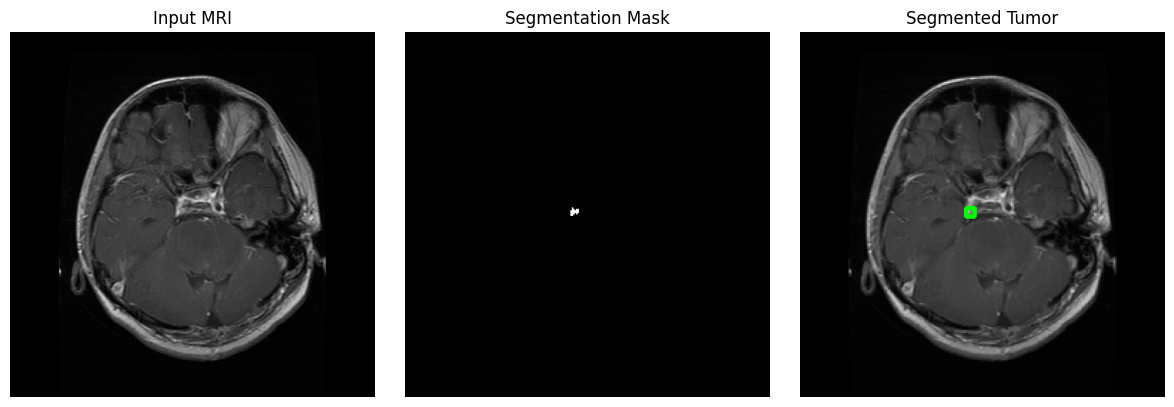

History saved for user: UNHRZfS3F0fI4ppnWk3NPc1nrL72


In [ ]:
import firebase_admin
from firebase_admin import credentials, db, storage
import tensorflow as tf
import cv2
import numpy as np
import requests
import tempfile
import matplotlib.pyplot as plt
import uuid
import time

# ==============================
# FIREBASE INIT
# ==============================

cred = credentials.Certificate("deepmriscan-firebase-adminsdk-fbsvc-6f374969f7.json")

firebase_admin.initialize_app(cred, {
    "databaseURL": "https://deepmriscan-default-rtdb.firebaseio.com/",
    "storageBucket": "deepmriscan.firebasestorage.app"
})

bucket = storage.bucket()

# ==============================
# LOAD MODELS
# ==============================

print("Loading AI models...")

class_model = tf.keras.models.load_model("model/best_brain_tumor_model.h5")
seg_model = tf.keras.models.load_model("model/brain_tumor_unet_segmentation.h5")

classes = ["glioma","meningioma","pituitary","no_tumor"]

CLASS_SIZE = 224
SEG_SIZE = 256

print("Models Loaded Successfully")

# ==============================
# DOWNLOAD IMAGE
# ==============================

def download_image(url):

    response = requests.get(url)

    temp = tempfile.NamedTemporaryFile(delete=False,suffix=".jpg")
    temp.write(response.content)
    temp.close()

    return temp.name


# ==============================
# UPLOAD SEGMENTED RESULT IMAGE
# ==============================

bucket = storage.bucket()

def upload_result_image(local_path, filename):

    blob = bucket.blob(f"results/{filename}")
    blob.upload_from_filename(local_path)

    blob.make_public()

    return blob.public_url


# ==============================
# MODEL INFERENCE
# ==============================

def run_model(image_path):

    img = cv2.imread(image_path)
    orig = img.copy()

    # ==============================
    # CLASSIFICATION
    # ==============================

    img_class = cv2.resize(img,(CLASS_SIZE,CLASS_SIZE))
    img_class = img_class/255.0
    img_class = np.expand_dims(img_class,axis=0)

    pred = class_model.predict(img_class)

    class_id = np.argmax(pred)
    predicted_class = classes[class_id]
    confidence = float(np.max(pred))*100

    # ==============================
    # SEGMENTATION
    # ==============================

    img_seg = cv2.resize(img,(SEG_SIZE,SEG_SIZE))
    img_seg_norm = img_seg/255.0
    img_seg_array = np.expand_dims(img_seg_norm,axis=0)

    bbox_img = img_seg.copy()
    mask_display = None

    if predicted_class != "no_tumor":

        seg_pred = seg_model.predict(img_seg_array)

        mask = seg_pred[0,:,:,0]
        mask = (mask > 0.5).astype(np.uint8)

        mask_display = mask*255

        contours,_ = cv2.findContours(
            mask_display.astype(np.uint8),
            cv2.RETR_EXTERNAL,
            cv2.CHAIN_APPROX_SIMPLE
        )

        for cnt in contours:

            x,y,w,h = cv2.boundingRect(cnt)

            cv2.rectangle(
                bbox_img,
                (x,y),
                (x+w,y+h),
                (0,255,0),
                2
            )

    # ==============================
    # SAVE SEGMENTED IMAGE
    # ==============================

    segmented_path = "segmented_result.jpg"
    cv2.imwrite(segmented_path, bbox_img)

    # ==============================
    # VISUALIZATION
    # ==============================

    plt.figure(figsize=(12,4))

    # Input Image
    plt.subplot(1,3,1)
    plt.imshow(cv2.cvtColor(orig,cv2.COLOR_BGR2RGB))
    plt.title("Input MRI")
    plt.axis("off")

    # Segmentation Mask
    plt.subplot(1,3,2)

    if mask_display is not None:
        plt.imshow(mask_display,cmap="gray")
    else:
        plt.text(0.3,0.5,"No Tumor",fontsize=14)

    plt.title("Segmentation Mask")
    plt.axis("off")

    # Segmented Result
    plt.subplot(1,3,3)
    plt.imshow(cv2.cvtColor(bbox_img,cv2.COLOR_BGR2RGB))
    plt.title("Segmented Tumor")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

    return predicted_class, confidence, segmented_path


# ==============================
# PROCESS FIREBASE UPLOADS
# ==============================

def process_uploads():

    users = db.reference("users").get()

    if users is None:
        return

    for user_id, user_data in users.items():

        if "liveUpload" not in user_data:
            continue

        live = user_data["liveUpload"]

        if live.get("isNew") == True:

            print("Processing MRI for:",user_id)

            image_url = live["imageUrl"]

            # download image
            image_path = download_image(image_url)

            # run AI model
            predicted_class, confidence, segmented_path = run_model(image_path)

            # upload segmented result
            result_url = upload_result_image(
                segmented_path,
                f"{user_id}_{uuid.uuid4()}.jpg"
            )

            timestamp = int(time.time()*1000)

            # update liveUpload node
            db.reference(f"users/{user_id}/liveUpload").update({
                "isNew": False
            })

            # save history record
            history_id = str(uuid.uuid4())

            history_data = {
                "inputImage": image_url,
                "segmentedImage": result_url,
                "prediction": predicted_class,
                "confidence": confidence,
                "timestamp": timestamp
            }

            db.reference(f"users/{user_id}/history/{history_id}").set(history_data)

            print("History saved for user:",user_id)


# ==============================
# MAIN LOOP
# ==============================

print("DeepMRIScan AI Server Started")

while True:

    process_uploads()

    time.sleep(5)